In [3]:
import pandas as pd
df=pd.read_csv("titanic.csv")
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
m=df["Age"].mean()
df["Age"].fillna(m,inplace=True)
m_e=df["Embarked"].mode()[0]
df["Embarked"].fillna(m_e,inplace=True)
df.drop("Cabin",axis=1,inplace=True)
df.drop_duplicates(subset="PassengerId",inplace=True)
df["Sex"]=df["Sex"].str.capitalize()
df["Age"]=df["Age"].astype(int)
df
#df["Pclass"]=df["Pclass"].astype(object)
df["Pclass"]=df["Pclass"].replace({1:"First class",2:"Second class",3:"Third class"})
df["Title"] = df["Name"].str.extract(r' ([A-Za-z]+)\.')
df["First"] = df["Name"].str.extract(r'\.\s*([A-Za-z"-]+)')
df["Name"]= df["Title"] + " " + df["First"]
df.drop(columns=["Title","First"],inplace=True)
df

C:\Users\niveditha\AppData\Local\Temp\ipykernel_19216\3318135489.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(m,inplace=True)
C:\Users\niveditha\AppData\Local\Temp\ipykernel_19216\3318135489.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,Third class,Mr Owen,Male,22,1,0,A/5 21171,7.2500,S
1,2,1,First class,Mrs John,Female,38,1,0,PC 17599,71.2833,C
2,3,1,Third class,Miss Laina,Female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,First class,Mrs Jacques,Female,35,1,0,113803,53.1000,S
4,5,0,Third class,Mr William,Male,35,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,Second class,Rev Juozas,Male,27,0,0,211536,13.0000,S
887,888,1,First class,Miss Margaret,Female,19,0,0,112053,30.0000,S
888,889,0,Third class,Miss Catherine,Female,29,1,2,W./C. 6607,23.4500,S
889,890,1,First class,Mr Karl,Male,26,0,0,111369,30.0000,C


Missing values in Age and Embarked were handled using mean and mode. 
The Cabin column was dropped due to too many missing values. 
Duplicate records were removed and categorical values were cleaned for better readability.

Sex
Female    233
Male      109
Name: Survived, dtype: int64
Pclass
First class     136
Second class     87
Third class     119
Name: Survived, dtype: int64


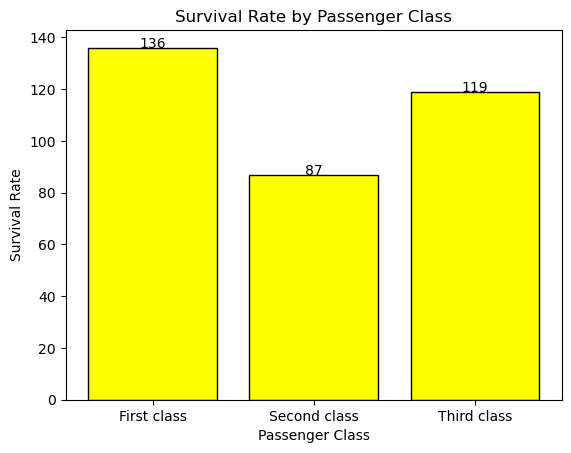

In [5]:
s_s=df.groupby("Sex")["Survived"].sum()
print(s_s)
p_s=df.groupby("Pclass")["Survived"].sum()
print(p_s)
import matplotlib.pyplot as plt
plt.bar(p_s.index,p_s.values,color="yellow",edgecolor="black")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
for i,value in enumerate(p_s):
    plt.text(i,value,round(value,3),ha="center")
plt.show()

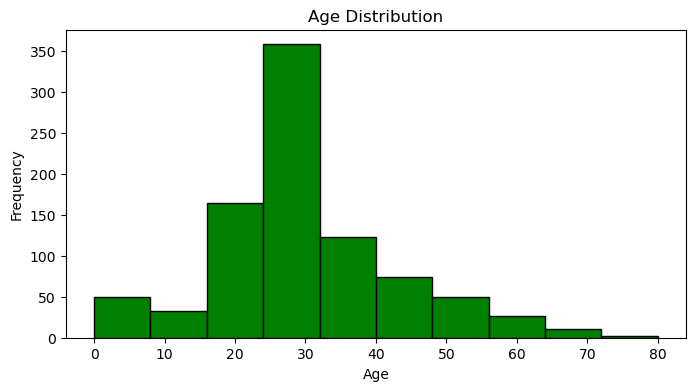

In [6]:
plt.figure(figsize=(8,4))
plt.hist(df["Age"],bins=10,edgecolor="black",color="green")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

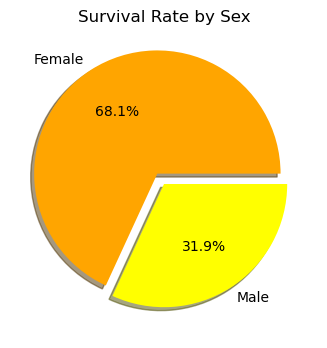

In [7]:
plt.figure(figsize=(8,4))
plt.pie(s_s.values,labels=s_s.index,autopct="%1.1f%%",explode=[0.1,0],shadow=True,colors=["orange","yellow"])
plt.title("Survival Rate by Sex")
plt.show()

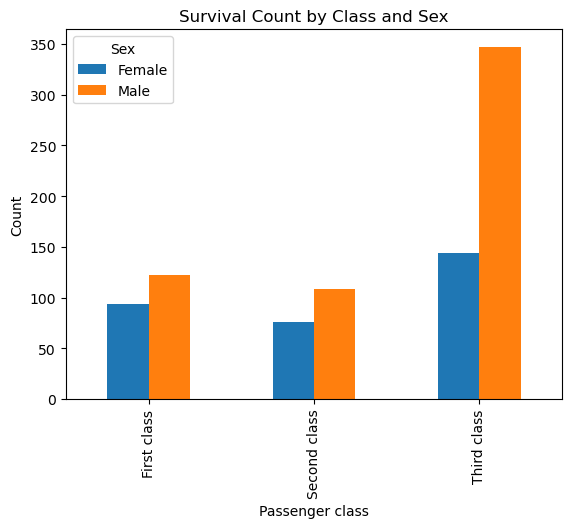

In [8]:
p_s = df.groupby(["Pclass", "Sex"])["Survived"].count().unstack()
p_s.plot(kind="bar")
plt.title("Survival Count by Class and Sex")
plt.xlabel("Passenger class")
plt.ylabel("Count")
plt.show()

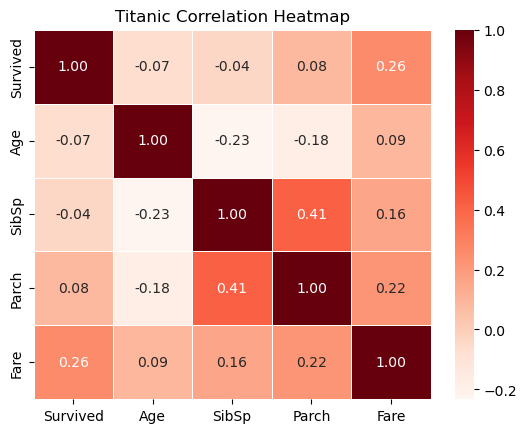

In [9]:
import seaborn as sns
numeric_df = df[["Survived", "Age", "SibSp", "Parch", "Fare"]]
cor=numeric_df.corr()
sns.heatmap(cor,annot=True,cmap="Reds",fmt=".2f",linewidths=0.5)
plt.title("Titanic Correlation Heatmap")
plt.show()

1.The dataset contains passenger details such as age, gender, class, and survival status.

2.Female passengers have a much higher survival rate compared to male passengers.

3.Passengers in first class had better survival chances than those in second and third class.

4.Most passengers are in the young to middle age group.(between 20-50)

5.Data cleaning improved the dataset by handling missing values and removing unnecessary columns.

# What I would explore next

I would like to explore how ticket fare affects survival chances.

I am curious to see if traveling with family influenced survival.

I would also analyze survival based on embarkation location.